In [1]:
import pandas as pd
import numpy as np
import joblib
import os

import skfuzzy as fuzz
from skfuzzy import control as ctrl

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
optimized_xgb = joblib.load(
    "models/optimized_xgboost.pkl"
)

model_config = joblib.load(
    "models/model_config.pkl"
)

print("Model loaded successfully.")
print("Model threshold:", model_config["threshold"])

Model loaded successfully.
Model threshold: 0.9500000000000001


In [4]:
fraud_prob = ctrl.Antecedent(
    np.arange(0, 101, 1),
    "fraud_probability"
)

amount_risk = ctrl.Antecedent(
    np.arange(0, 101, 1),
    "amount_risk"
)

anomaly_score = ctrl.Antecedent(
    np.arange(0, 101, 1),
    "anomaly_score"
)

risk = ctrl.Consequent(
    np.arange(0, 101, 1),
    "risk"
)
# Fraud Probability

fraud_prob["low"] = fuzz.trapmf(
    fraud_prob.universe,
    [0, 0, 20, 40]
)

fraud_prob["medium"] = fuzz.trimf(
    fraud_prob.universe,
    [25, 50, 75]
)

fraud_prob["high"] = fuzz.trapmf(
    fraud_prob.universe,
    [60, 80, 100, 100]
)


# Amount Risk

amount_risk["low"] = fuzz.trapmf(
    amount_risk.universe,
    [0, 0, 20, 40]
)

amount_risk["medium"] = fuzz.trimf(
    amount_risk.universe,
    [25, 50, 75]
)

amount_risk["high"] = fuzz.trapmf(
    amount_risk.universe,
    [60, 80, 100, 100]
)


# Anomaly Score

anomaly_score["low"] = fuzz.trapmf(
    anomaly_score.universe,
    [0, 0, 20, 40]
)

anomaly_score["medium"] = fuzz.trimf(
    anomaly_score.universe,
    [25, 50, 75]
)

anomaly_score["high"] = fuzz.trapmf(
    anomaly_score.universe,
    [60, 80, 100, 100]
)


# Risk Output

risk["low"] = fuzz.trapmf(
    risk.universe,
    [0, 0, 20, 40]
)

risk["medium"] = fuzz.trimf(
    risk.universe,
    [30, 50, 70]
)

risk["high"] = fuzz.trapmf(
    risk.universe,
    [60, 80, 100, 100]
)

In [5]:
rule1 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["low"] &
    anomaly_score["low"],
    risk["low"]
)

rule2 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["medium"] &
    anomaly_score["low"],
    risk["low"]
)

rule3 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["low"] &
    anomaly_score["medium"],
    risk["medium"]
)

rule4 = ctrl.Rule(
    fraud_prob["medium"] &
    amount_risk["low"] &
    anomaly_score["low"],
    risk["medium"]
)

rule5 = ctrl.Rule(
    fraud_prob["medium"] &
    amount_risk["medium"] &
    anomaly_score["low"],
    risk["medium"]
)

rule6 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["high"] &
    anomaly_score["low"],
    risk["medium"]
)

rule7 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["medium"] &
    anomaly_score["medium"],
    risk["medium"]
)

rule8 = ctrl.Rule(
    fraud_prob["medium"] &
    amount_risk["low"] &
    anomaly_score["medium"],
    risk["medium"]
)

rule9 = ctrl.Rule(
    fraud_prob["high"],
    risk["high"]
)

rule10 = ctrl.Rule(
    fraud_prob["medium"] &
    anomaly_score["high"],
    risk["high"]
)

rule11 = ctrl.Rule(
    fraud_prob["medium"] &
    amount_risk["high"],
    risk["high"]
)

rule12 = ctrl.Rule(
    amount_risk["high"] &
    anomaly_score["high"],
    risk["high"]
)

rule13 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["high"] &
    anomaly_score["medium"],
    risk["high"]
)

rule14 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["medium"] &
    anomaly_score["high"],
    risk["high"]
)

rule15 = ctrl.Rule(
    fraud_prob["low"] &
    amount_risk["high"] &
    anomaly_score["high"],
    risk["high"]
)

In [6]:
risk_control = ctrl.ControlSystem([
    rule1,
    rule2,
    rule3,
    rule4,
    rule5,
    rule6,
    rule7,
    rule8,
    rule9,
    rule10,
    rule11,
    rule12,
    rule13,
    rule14,
    rule15
])

print("Fuzzy risk engine initialized.")

Fuzzy risk engine initialized.


In [7]:
df = pd.read_csv("creditcard.csv")

print("Dataset loaded:", df.shape)
df["Log_Amount"] = np.log1p(df["Amount"])

df["Hour"] = (
    (df["Time"] / 3600) % 24
)
v_features = [
    f"V{i}" for i in range(1, 29)
]

Dataset loaded: (284807, 31)


In [9]:
from sklearn.preprocessing import StandardScaler

legitimate_data = df.loc[
    df["Class"] == 0,
    v_features
]

anomaly_scaler = StandardScaler()

legitimate_scaled = anomaly_scaler.fit_transform(
    legitimate_data
)

legitimate_centroid = legitimate_scaled.mean(
    axis=0
)

print("Anomaly scoring system initialized.")

Anomaly scoring system initialized.


In [15]:
def analyze_transaction(transaction):

    transaction = transaction.copy()

    # -----------------------------
    # Feature Engineering
    # -----------------------------

    transaction["Log_Amount"] = np.log1p(
        transaction["Amount"]
    )

    transaction["Hour"] = (
        transaction["Time"] / 3600
    ) % 24

    feature_columns = (
        ["Time"]
        + [f"V{i}" for i in range(1, 29)]
        + ["Amount", "Log_Amount", "Hour"]
    )

    X_transaction = pd.DataFrame(
        [transaction[feature_columns]]
    )

    # -----------------------------
    # ML Fraud Prediction
    # -----------------------------

    fraud_probability = optimized_xgb.predict_proba(
        X_transaction
    )[0, 1]

    threshold = model_config["threshold"]

    if fraud_probability >= threshold:
        ml_decision = "FRAUD"
    else:
        ml_decision = "LEGITIMATE"

    # -----------------------------
    # Amount Risk
    # -----------------------------

    amount_risk_value = (
        (df["Amount"] <= transaction["Amount"]).mean()
        * 100
    )

    # -----------------------------
    # Anomaly Score
    # -----------------------------

    transaction_v = pd.DataFrame(
    [[
        transaction[f"V{i}"]
        for i in range(1, 29)
    ]],
    columns=v_features
)

    transaction_scaled = anomaly_scaler.transform(
    transaction_v
)

    anomaly_distance = np.sqrt(
        (
            transaction_scaled
            - legitimate_centroid
        ) ** 2
    ).sum() ** 0.5

    legitimate_distances = np.sqrt(
        (
            legitimate_scaled
            - legitimate_centroid
        ) ** 2
    ).sum(axis=1) ** 0.5

    anomaly_score_value = (
        np.mean(
            legitimate_distances <= anomaly_distance
        ) * 100
    )

    # -----------------------------
    # Fuzzy Risk Assessment
    # -----------------------------

    simulation = ctrl.ControlSystemSimulation(
        risk_control
    )

    simulation.input[
        "fraud_probability"
    ] = fraud_probability * 100

    simulation.input[
        "amount_risk"
    ] = amount_risk_value

    simulation.input[
        "anomaly_score"
    ] = anomaly_score_value

    try:

        simulation.compute()

        fuzzy_risk_score = simulation.output["risk"]

    except (KeyError, ValueError):

        # Fallback for uncovered fuzzy combinations
        fuzzy_risk_score = (
            0.60 * fraud_probability * 100
            + 0.20 * amount_risk_value
            + 0.20 * anomaly_score_value
        )

        fuzzy_risk_score = np.clip(
            fuzzy_risk_score,
            0,
            100
        )

    # -----------------------------
    # Risk Level
    # -----------------------------

    if fuzzy_risk_score < 30:
        risk_level = "LOW"

    elif fuzzy_risk_score < 70:
        risk_level = "MEDIUM"

    else:
        risk_level = "HIGH"

    return {
        "Fraud Probability": fraud_probability,
        "ML Decision": ml_decision,
        "Amount Risk": amount_risk_value,
        "Anomaly Score": anomaly_score_value,
        "Fuzzy Risk Score": fuzzy_risk_score,
        "Risk Level": risk_level
    }

In [12]:
print("analyze_transaction function created successfully.")

analyze_transaction function created successfully.


In [16]:
test_transaction = df.iloc[0].copy()

result = analyze_transaction(test_transaction)

print(result)

{'Fraud Probability': np.float32(1.8931449e-05), 'ML Decision': 'LEGITIMATE', 'Amount Risk': np.float64(85.9332811342418), 'Anomaly Score': np.float64(11.193570511580466), 'Fuzzy Risk Score': np.float64(49.99999999999999), 'Risk Level': 'MEDIUM'}


In [17]:
print("=" * 45)
print(" AI FINANCIAL FRAUD DETECTION SYSTEM")
print("=" * 45)

print(
    f"Fraud Probability : "
    f"{result['Fraud Probability'] * 100:.2f}%"
)

print(
    f"ML Decision       : "
    f"{result['ML Decision']}"
)

print(
    f"Amount Risk       : "
    f"{result['Amount Risk']:.2f}"
)

print(
    f"Anomaly Score     : "
    f"{result['Anomaly Score']:.2f}"
)

print(
    f"Fuzzy Risk Score  : "
    f"{result['Fuzzy Risk Score']:.2f}"
)

print(
    f"Risk Level        : "
    f"{result['Risk Level']}"
)

print("=" * 45)

 AI FINANCIAL FRAUD DETECTION SYSTEM
Fraud Probability : 0.00%
ML Decision       : LEGITIMATE
Amount Risk       : 85.93
Anomaly Score     : 11.19
Fuzzy Risk Score  : 50.00
Risk Level        : MEDIUM


In [20]:
print("Actual Class:", fraud_transaction["Class"])

print("Fraud Probability:",
      fraud_result["Fraud Probability"] * 100)

print("Amount Risk:",
      fraud_result["Amount Risk"])

print("Anomaly Score:",
      fraud_result["Anomaly Score"])

print("Fuzzy Risk Score:",
      fraud_result["Fuzzy Risk Score"])

NameError: name 'fraud_transaction' is not defined

In [21]:
# Select an actual fraudulent transaction
fraud_transaction = df[
    df["Class"] == 1
].iloc[0].copy()

# Analyze it
fraud_result = analyze_transaction(
    fraud_transaction
)

print("Actual Class:", fraud_transaction["Class"])
print(
    "Fraud Probability:",
    fraud_result["Fraud Probability"] * 100
)
print(
    "Amount Risk:",
    fraud_result["Amount Risk"]
)
print(
    "Anomaly Score:",
    fraud_result["Anomaly Score"]
)
print(
    "Fuzzy Risk Score:",
    fraud_result["Fuzzy Risk Score"]
)
print(
    "Risk Level:",
    fraud_result["Risk Level"]
)

Actual Class: 1.0
Fraud Probability: 99.99094
Amount Risk: 0.6407848121710491
Anomaly Score: 97.52141111091571
Fuzzy Risk Score: 84.44444444444444
Risk Level: HIGH


In [23]:
# Select three representative transactions

legitimate_transaction = df[
    df["Class"] == 0
].iloc[0].copy()

fraud_transaction = df[
    df["Class"] == 1
].iloc[0].copy()

# Analyze the first legitimate transaction
legitimate_result = analyze_transaction(
    legitimate_transaction
)

# Analyze the first fraud transaction
fraud_result = analyze_transaction(
    fraud_transaction
)

# Find the strongest fraud transaction WITHOUT
# relying on a Fraud_Probability column
fraud_candidates = df[
    df["Class"] == 1
].copy()

fraud_probabilities = optimized_xgb.predict_proba(
    fraud_candidates[
        ["Time"]
        + [f"V{i}" for i in range(1, 29)]
        + ["Amount", "Log_Amount", "Hour"]
    ]
)[:, 1]

strongest_index = np.argmax(fraud_probabilities)

high_probability_fraud = fraud_candidates.iloc[
    strongest_index
].copy()

strong_fraud_result = analyze_transaction(
    high_probability_fraud
)

# Create comparison table

comparison = pd.DataFrame([
    {
        "Type": "Legitimate",
        **legitimate_result
    },
    {
        "Type": "Fraud Sample",
        **fraud_result
    },
    {
        "Type": "Strong Fraud",
        **strong_fraud_result
    }
])

comparison

,Type,Fraud Probability,ML Decision,Amount Risk,Anomaly Score,Fuzzy Risk Score,Risk Level
0,Legitimate,0.000019,LEGITIMATE,85.933281,11.193571,50.000000,MEDIUM
1,Fraud Sample,0.999909,FRAUD,0.640785,97.521411,84.444444,HIGH
2,Strong Fraud,1.000000,FRAUD,87.998890,99.748167,84.444444,HIGH


In [24]:
import joblib
import os

os.makedirs("models", exist_ok=True)

joblib.dump(
    anomaly_scaler,
    "models/anomaly_scaler.pkl"
)

joblib.dump(
    legitimate_centroid,
    "models/legitimate_centroid.pkl"
)

joblib.dump(
    legitimate_scaled,
    "models/legitimate_scaled.pkl"
)

print("Fuzzy preprocessing objects saved successfully.")

Fuzzy preprocessing objects saved successfully.


In [25]:
fuzzy_config = {
    "fraud_probability": {
        "low": [0, 0, 20, 40],
        "medium": [25, 50, 75],
        "high": [60, 80, 100, 100]
    },

    "amount_risk": {
        "low": [0, 0, 20, 40],
        "medium": [25, 50, 75],
        "high": [60, 80, 100, 100]
    },

    "anomaly_score": {
        "low": [0, 0, 20, 40],
        "medium": [25, 50, 75],
        "high": [60, 80, 100, 100]
    },

    "risk": {
        "low": [0, 0, 20, 40],
        "medium": [30, 50, 70],
        "high": [60, 80, 100, 100]
    },

    "risk_thresholds": {
        "low_max": 30,
        "medium_max": 70
    },

    "num_rules": 15
}

joblib.dump(
    fuzzy_config,
    "models/fuzzy_config.pkl"
)

print("Fuzzy configuration saved successfully.")

Fuzzy configuration saved successfully.


In [26]:
model_files = [
    "optimized_xgboost.pkl",
    "model_config.pkl",
    "anomaly_scaler.pkl",
    "legitimate_centroid.pkl",
    "legitimate_scaled.pkl",
    "fuzzy_config.pkl"
]

print("Saved model files:")
print("-" * 40)

for file in model_files:
    path = os.path.join("models", file)

    if os.path.exists(path):
        size = os.path.getsize(path) / (1024 * 1024)
        print(f"✓ {file} ({size:.2f} MB)")
    else:
        print(f"✗ {file} NOT FOUND")

Saved model files:
----------------------------------------
✓ optimized_xgboost.pkl (0.88 MB)
✓ model_config.pkl (0.00 MB)
✓ anomaly_scaler.pkl (0.00 MB)
✓ legitimate_centroid.pkl (0.00 MB)
✓ legitimate_scaled.pkl (60.74 MB)
✓ fuzzy_config.pkl (0.00 MB)


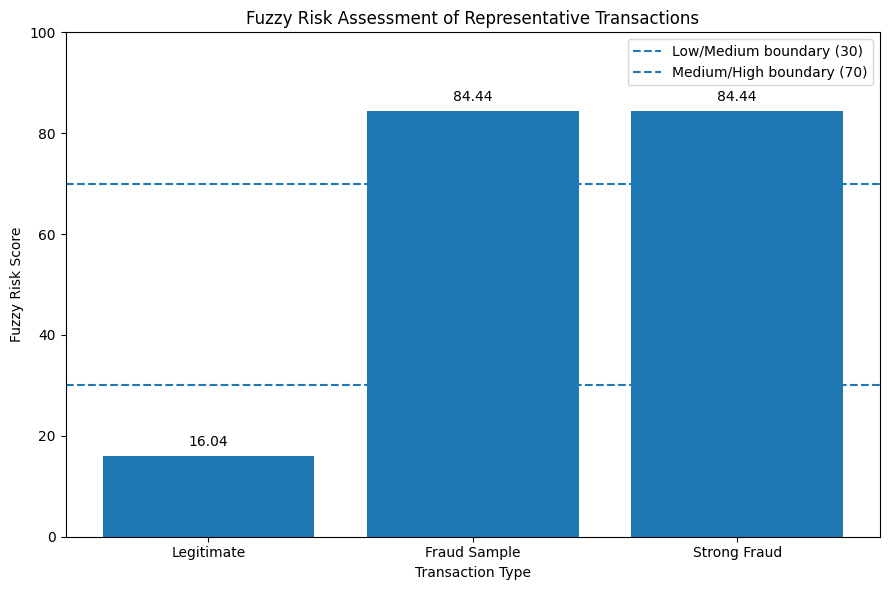

In [27]:
import matplotlib.pyplot as plt

# Representative transactions from the final system
transaction_types = [
    "Legitimate",
    "Fraud Sample",
    "Strong Fraud"
]

fuzzy_scores = [
    16.04,
    84.44,
    84.44
]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    transaction_types,
    fuzzy_scores
)

plt.axhline(
    y=30,
    linestyle="--",
    label="Low/Medium boundary (30)"
)

plt.axhline(
    y=70,
    linestyle="--",
    label="Medium/High boundary (70)"
)

plt.ylabel("Fuzzy Risk Score")
plt.xlabel("Transaction Type")
plt.title("Fuzzy Risk Assessment of Representative Transactions")
plt.ylim(0, 100)
plt.legend()

# Display values above bars
for bar, score in zip(bars, fuzzy_scores):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 2,
        f"{score:.2f}",
        ha="center"
    )

plt.tight_layout()

plt.savefig(
    "fuzzy_risk.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()